### Cell 1 — Mount + imports + paths

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import json
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

BASE_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose")
SPLIT_DIR = BASE_DIR / "data" / "splits"
CKPT_DIR = BASE_DIR / "outputs" / "checkpoints"
OUT_DIR = BASE_DIR / "analysis" / "ct2dose_phase4_beam_aware_mixed_training"

OUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_MANIFEST = SPLIT_DIR / "train_pairs_3d_train_phase3_2000.json"
VAL_MANIFEST   = SPLIT_DIR / "train_pairs_3d_val_phase3_500.json"

print("TRAIN_MANIFEST exists:", TRAIN_MANIFEST.exists())
print("VAL_MANIFEST exists:", VAL_MANIFEST.exists())

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

Mounted at /content/drive
TRAIN_MANIFEST exists: True
VAL_MANIFEST exists: True
device: cuda


### Cell 2 — Title

In [2]:
from IPython.display import Markdown, display

display(Markdown(r"""
# CT-to-Dose Phase 4: Beam-Aware Mixed Training
## Goal
Keep the current balanced mixed-loss setup and add a geometry-aware beam-axis weighting term.
"""))


# CT-to-Dose Phase 4: Beam-Aware Mixed Training
## Goal
Keep the current balanced mixed-loss setup and add a geometry-aware beam-axis weighting term.


### Cell 3 — Dataset + model definitions

In [3]:
DOSE_SCALE = 1000.0
EPS = 1e-8

def normalize_ct(x):
    x = np.clip(x, -1024.0, 1500.0)
    x = (x + 1024.0) / (1500.0 + 1024.0)
    return x.astype(np.float32)

class CubePair3DDataset(Dataset):
    def __init__(self, manifest_path, dose_scale=1000.0):
        with open(manifest_path, "r", encoding="utf-8") as f:
            self.records = json.load(f)
        self.dose_scale = dose_scale

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        x0 = np.load(rec["input_path"]).astype(np.float32)
        x1 = np.load(rec["output_path"]).astype(np.float32)

        x0 = normalize_ct(x0)
        x1 = (x1 * self.dose_scale).astype(np.float32)

        x0 = torch.from_numpy(x0).unsqueeze(0)   # (1,D,H,W)
        x1 = torch.from_numpy(x1).unsqueeze(0)   # (1,D,H,W)

        return x0, x1


class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ConditionalUNetFlow3D(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base_ch=24):
        super().__init__()

        self.enc1 = DoubleConv3D(in_ch, base_ch)
        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv3D(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv3D(base_ch * 2, base_ch * 4)

        self.up2 = nn.ConvTranspose3d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv3D(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose3d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = DoubleConv3D(base_ch * 2, base_ch)

        self.out_conv = nn.Conv3d(base_ch, out_ch, kernel_size=1)

    def forward(self, xt, x0, t):
        t_map = t.expand(-1, 1, xt.shape[2], xt.shape[3], xt.shape[4])
        inp = torch.cat([xt, x0, t_map], dim=1)

        e1 = self.enc1(inp)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)


@torch.no_grad()
def euler_sample_flow_3d(model, x0, n_steps=30):
    model.eval()
    z = x0.clone()
    dt = 1.0 / n_steps

    for k in range(n_steps):
        t = torch.full((z.shape[0], 1, 1, 1, 1), k / n_steps, device=z.device)
        v = model(z, x0, t)
        z = z + dt * v

    return z


def sample_t_like(x):
    return torch.rand((x.shape[0], 1, 1, 1, 1), device=x.device)

### Cell 4 — Config

In [4]:
RUN_NAME = "ct2dose_phase4_beam_aware_mixed_flow_lr5e4_base24_bs2_T0p15_a0p30_mw3_g1_sz2_sy3_mt4"

LR = 5e-4
BATCH_SIZE = 2
EPOCHS = 50
BASE_CH = 24

THRESHOLD = 0.15
THRESHOLD_MODE = "absolute"

ALPHA = 0.30
MAX_DOSE_WEIGHT = 3.0

# new beam-aware geometry term
BEAM_GAMMA = 1.0
SIGMA_Z = 2.0
SIGMA_Y = 3.0
MAX_TOTAL_WEIGHT = 4.0

best_ckpt_path = CKPT_DIR / f"{RUN_NAME}_best.pt"
latest_ckpt_path = CKPT_DIR / f"{RUN_NAME}_latest.pt"
log_csv_path = OUT_DIR / f"{RUN_NAME}_training_log.csv"
summary_json_path = OUT_DIR / f"{RUN_NAME}_summary.json"

print("RUN_NAME:", RUN_NAME)
print("THRESHOLD:", THRESHOLD)
print("ALPHA:", ALPHA)
print("MAX_DOSE_WEIGHT:", MAX_DOSE_WEIGHT)
print("BEAM_GAMMA:", BEAM_GAMMA)
print("SIGMA_Z:", SIGMA_Z)
print("SIGMA_Y:", SIGMA_Y)
print("MAX_TOTAL_WEIGHT:", MAX_TOTAL_WEIGHT)

RUN_NAME: ct2dose_phase4_beam_aware_mixed_flow_lr5e4_base24_bs2_T0p15_a0p30_mw3_g1_sz2_sy3_mt4
THRESHOLD: 0.15
ALPHA: 0.3
MAX_DOSE_WEIGHT: 3.0
BEAM_GAMMA: 1.0
SIGMA_Z: 2.0
SIGMA_Y: 3.0
MAX_TOTAL_WEIGHT: 4.0


### Cell 5 — Beam center + weight-map helpers

In [5]:
def infer_beam_center_from_gt(gt_dose):
    """
    gt_dose: [B,1,D,H,W]
    Beam direction assumed along W (x direction).
    We project along W, then find the peak in the D-H plane.
    """
    proj = gt_dose[:, 0].sum(dim=-1)   # [B,D,H]
    B, D, H = proj.shape
    flat_idx = proj.reshape(B, -1).argmax(dim=1)
    zc = flat_idx // H
    yc = flat_idx % H
    return zc, yc


def build_dose_weight_map_from_gt(gt_dose, threshold=0.15, mode="absolute", eps=1e-8):
    if mode == "absolute":
        T = torch.full_like(gt_dose, fill_value=threshold)
    elif mode == "relative_to_case_max":
        case_max = gt_dose.amax(dim=(1,2,3,4), keepdim=True)
        T = threshold * case_max.expand_as(gt_dose)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    T = torch.clamp(T, min=eps)
    weight = torch.maximum(T, gt_dose) / T
    return weight


def build_beam_axis_weight_map(gt_dose, gamma=1.0, sigma_z=2.0, sigma_y=3.0):
    """
    Returns a spatial weighting map emphasizing voxels near the inferred beam axis.
    gt_dose: [B,1,D,H,W]
    """
    B, _, D, H, W = gt_dose.shape
    zc, yc = infer_beam_center_from_gt(gt_dose)

    z_grid = torch.arange(D, device=gt_dose.device, dtype=torch.float32).view(1, 1, D, 1, 1)
    y_grid = torch.arange(H, device=gt_dose.device, dtype=torch.float32).view(1, 1, 1, H, 1)

    zc = zc.view(B, 1, 1, 1, 1).float()
    yc = yc.view(B, 1, 1, 1, 1).float()

    dist2 = ((z_grid - zc) / sigma_z) ** 2 + ((y_grid - yc) / sigma_y) ** 2
    beam_weight = 1.0 + gamma * torch.exp(-0.5 * dist2)
    beam_weight = beam_weight.expand(B, 1, D, H, W)
    return beam_weight

### Cell 6 — Beam-aware mixed loss

In [6]:
def compute_beam_aware_mixed_flow_matching_loss(
    model,
    x0,
    x1,
    threshold=0.15,
    mode="absolute",
    alpha=0.30,
    max_dose_weight=3.0,
    beam_gamma=1.0,
    sigma_z=2.0,
    sigma_y=3.0,
    max_total_weight=4.0,
    eps=1e-8
):
    """
    base_loss:
        mean((v_pred - v_target)^2)

    beam-aware weighted loss:
        sum(w_total * sq_err) / sum(w_total)

    final_loss:
        (1-alpha)*base_loss + alpha*beam_weighted_loss
    """
    t = sample_t_like(x0)
    z_t = (1.0 - t) * x0 + t * x1

    v_target = x1 - x0
    v_pred = model(z_t, x0, t)

    sq_err = (v_pred - v_target) ** 2
    base_loss = sq_err.mean()

    dose_weight = build_dose_weight_map_from_gt(
        x1, threshold=threshold, mode=mode, eps=eps
    )
    if max_dose_weight is not None:
        dose_weight = torch.clamp(dose_weight, max=max_dose_weight)

    beam_weight = build_beam_axis_weight_map(
        x1, gamma=beam_gamma, sigma_z=sigma_z, sigma_y=sigma_y
    )

    total_weight = dose_weight * beam_weight
    if max_total_weight is not None:
        total_weight = torch.clamp(total_weight, max=max_total_weight)

    beam_weighted_loss = (total_weight * sq_err).sum() / (total_weight.sum() + eps)
    final_loss = (1.0 - alpha) * base_loss + alpha * beam_weighted_loss

    aux = {
        "base_loss": float(base_loss.item()),
        "beam_weighted_loss": float(beam_weighted_loss.item()),
        "final_loss": float(final_loss.item()),
        "dose_weight_mean": float(dose_weight.mean().item()),
        "beam_weight_mean": float(beam_weight.mean().item()),
        "total_weight_mean": float(total_weight.mean().item()),
        "total_weight_max": float(total_weight.max().item()),
    }
    return final_loss, aux

### Cell 7 — Datasets and loaders

In [7]:
train_dataset_3d = CubePair3DDataset(TRAIN_MANIFEST, dose_scale=DOSE_SCALE)
val_dataset_3d   = CubePair3DDataset(VAL_MANIFEST, dose_scale=DOSE_SCALE)

train_loader_3d = DataLoader(
    train_dataset_3d,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader_3d = DataLoader(
    val_dataset_3d,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train samples:", len(train_dataset_3d))
print("Val samples:", len(val_dataset_3d))

Train samples: 2000
Val samples: 500


### Cell 8 — Train / validation loops

In [8]:
def train_one_epoch_beam_aware(model, loader, optimizer, device):
    model.train()

    total_final = 0.0
    total_base = 0.0
    total_beam_weighted = 0.0
    total_dose_w_mean = 0.0
    total_beam_w_mean = 0.0
    total_total_w_mean = 0.0
    total_total_w_max = 0.0
    total_count = 0

    for x0, x1 in loader:
        x0 = x0.to(device)
        x1 = x1.to(device)

        loss, aux = compute_beam_aware_mixed_flow_matching_loss(
            model,
            x0, x1,
            threshold=THRESHOLD,
            mode=THRESHOLD_MODE,
            alpha=ALPHA,
            max_dose_weight=MAX_DOSE_WEIGHT,
            beam_gamma=BEAM_GAMMA,
            sigma_z=SIGMA_Z,
            sigma_y=SIGMA_Y,
            max_total_weight=MAX_TOTAL_WEIGHT,
            eps=EPS
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bs = x0.shape[0]
        total_final += aux["final_loss"] * bs
        total_base += aux["base_loss"] * bs
        total_beam_weighted += aux["beam_weighted_loss"] * bs
        total_dose_w_mean += aux["dose_weight_mean"] * bs
        total_beam_w_mean += aux["beam_weight_mean"] * bs
        total_total_w_mean += aux["total_weight_mean"] * bs
        total_total_w_max += aux["total_weight_max"] * bs
        total_count += bs

    return {
        "train_final_loss": total_final / total_count,
        "train_base_loss": total_base / total_count,
        "train_beam_weighted_loss": total_beam_weighted / total_count,
        "train_dose_weight_mean": total_dose_w_mean / total_count,
        "train_beam_weight_mean": total_beam_w_mean / total_count,
        "train_total_weight_mean": total_total_w_mean / total_count,
        "train_total_weight_max": total_total_w_max / total_count,
    }


@torch.no_grad()
def validate_one_epoch_beam_aware(model, loader, device):
    model.eval()

    total_final = 0.0
    total_base = 0.0
    total_beam_weighted = 0.0
    total_dose_w_mean = 0.0
    total_beam_w_mean = 0.0
    total_total_w_mean = 0.0
    total_total_w_max = 0.0
    total_count = 0

    for x0, x1 in loader:
        x0 = x0.to(device)
        x1 = x1.to(device)

        loss, aux = compute_beam_aware_mixed_flow_matching_loss(
            model,
            x0, x1,
            threshold=THRESHOLD,
            mode=THRESHOLD_MODE,
            alpha=ALPHA,
            max_dose_weight=MAX_DOSE_WEIGHT,
            beam_gamma=BEAM_GAMMA,
            sigma_z=SIGMA_Z,
            sigma_y=SIGMA_Y,
            max_total_weight=MAX_TOTAL_WEIGHT,
            eps=EPS
        )

        bs = x0.shape[0]
        total_final += aux["final_loss"] * bs
        total_base += aux["base_loss"] * bs
        total_beam_weighted += aux["beam_weighted_loss"] * bs
        total_dose_w_mean += aux["dose_weight_mean"] * bs
        total_beam_w_mean += aux["beam_weight_mean"] * bs
        total_total_w_mean += aux["total_weight_mean"] * bs
        total_total_w_max += aux["total_weight_max"] * bs
        total_count += bs

    return {
        "val_final_loss": total_final / total_count,
        "val_base_loss": total_base / total_count,
        "val_beam_weighted_loss": total_beam_weighted / total_count,
        "val_dose_weight_mean": total_dose_w_mean / total_count,
        "val_beam_weight_mean": total_beam_w_mean / total_count,
        "val_total_weight_mean": total_total_w_mean / total_count,
        "val_total_weight_max": total_total_w_max / total_count,
    }

### Cell 9 — Build model + optimizer

In [9]:
model = ConditionalUNetFlow3D(in_ch=3, out_ch=1, base_ch=BASE_CH).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = []
best_val_loss = float("inf")
best_epoch = -1
start_time = time.time()

print("Model initialized.")

Model initialized.


### Cell 10 — Main training loop

In [10]:
for epoch in range(1, EPOCHS + 1):
    train_stats = train_one_epoch_beam_aware(model, train_loader_3d, optimizer, device)
    val_stats = validate_one_epoch_beam_aware(model, val_loader_3d, device)

    row = {"epoch": epoch, **train_stats, **val_stats}
    history.append(row)

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "run_name": RUN_NAME,
        "threshold": THRESHOLD,
        "threshold_mode": THRESHOLD_MODE,
        "alpha": ALPHA,
        "max_dose_weight": MAX_DOSE_WEIGHT,
        "beam_gamma": BEAM_GAMMA,
        "sigma_z": SIGMA_Z,
        "sigma_y": SIGMA_Y,
        "max_total_weight": MAX_TOTAL_WEIGHT,
        "lr": LR,
        "base_ch": BASE_CH,
    }, latest_ckpt_path)

    if val_stats["val_final_loss"] < best_val_loss:
        best_val_loss = val_stats["val_final_loss"]
        best_epoch = epoch
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "run_name": RUN_NAME,
            "threshold": THRESHOLD,
            "threshold_mode": THRESHOLD_MODE,
            "alpha": ALPHA,
            "max_dose_weight": MAX_DOSE_WEIGHT,
            "beam_gamma": BEAM_GAMMA,
            "sigma_z": SIGMA_Z,
            "sigma_y": SIGMA_Y,
            "max_total_weight": MAX_TOTAL_WEIGHT,
            "lr": LR,
            "base_ch": BASE_CH,
            "best_val_loss": best_val_loss,
        }, best_ckpt_path)

    print(
        f"Epoch {epoch:03d} | "
        f"train_final={train_stats['train_final_loss']:.6e} | "
        f"val_final={val_stats['val_final_loss']:.6e} | "
        f"train_base={train_stats['train_base_loss']:.6e} | "
        f"val_base={val_stats['val_base_loss']:.6e} | "
        f"train_beamw={train_stats['train_beam_weighted_loss']:.6e} | "
        f"val_beamw={val_stats['val_beam_weighted_loss']:.6e} | "
        f"beam_w_mean={train_stats['train_beam_weight_mean']:.3f} | "
        f"total_w_mean={train_stats['train_total_weight_mean']:.3f}"
    )

elapsed_min = (time.time() - start_time) / 60.0
print("Training finished. elapsed_min =", elapsed_min)

Epoch 001 | train_final=4.322647e-03 | val_final=7.993084e-04 | train_base=3.941485e-03 | val_base=7.693571e-04 | train_beamw=5.212026e-03 | val_beamw=8.691950e-04 | beam_w_mean=1.037 | total_w_mean=1.068
Epoch 002 | train_final=6.146218e-04 | val_final=3.524191e-04 | train_base=5.838440e-04 | val_base=3.240354e-04 | train_beamw=6.864369e-04 | val_beamw=4.186475e-04 | beam_w_mean=1.037 | total_w_mean=1.068
Epoch 003 | train_final=3.468367e-04 | val_final=2.095774e-04 | train_base=3.283458e-04 | val_base=1.916309e-04 | train_beamw=3.899823e-04 | val_beamw=2.514525e-04 | beam_w_mean=1.037 | total_w_mean=1.068
Epoch 004 | train_final=2.828614e-04 | val_final=1.927624e-04 | train_base=2.637251e-04 | val_base=1.812825e-04 | train_beamw=3.275126e-04 | val_beamw=2.195488e-04 | beam_w_mean=1.037 | total_w_mean=1.068
Epoch 005 | train_final=2.470163e-04 | val_final=1.523054e-04 | train_base=2.328503e-04 | val_base=1.297944e-04 | train_beamw=2.800705e-04 | val_beamw=2.048312e-04 | beam_w_mean=1.

### Cell 11 — Save logs and summary

In [11]:
history_df = pd.DataFrame(history)
history_df.to_csv(log_csv_path, index=False)

summary = {
    "run_name": RUN_NAME,
    "epochs": EPOCHS,
    "lr": LR,
    "base_ch": BASE_CH,
    "batch_size": BATCH_SIZE,
    "threshold": THRESHOLD,
    "threshold_mode": THRESHOLD_MODE,
    "alpha": ALPHA,
    "max_dose_weight": MAX_DOSE_WEIGHT,
    "beam_gamma": BEAM_GAMMA,
    "sigma_z": SIGMA_Z,
    "sigma_y": SIGMA_Y,
    "max_total_weight": MAX_TOTAL_WEIGHT,
    "best_epoch": best_epoch,
    "best_val_loss": float(best_val_loss),
    "elapsed_min": float(elapsed_min),
    "best_ckpt_path": str(best_ckpt_path),
    "latest_ckpt_path": str(latest_ckpt_path),
}

with open(summary_json_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved:", log_csv_path)
print("Saved:", summary_json_path)
print(json.dumps(summary, indent=2))

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_beam_aware_mixed_training/ct2dose_phase4_beam_aware_mixed_flow_lr5e4_base24_bs2_T0p15_a0p30_mw3_g1_sz2_sy3_mt4_training_log.csv
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_beam_aware_mixed_training/ct2dose_phase4_beam_aware_mixed_flow_lr5e4_base24_bs2_T0p15_a0p30_mw3_g1_sz2_sy3_mt4_summary.json
{
  "run_name": "ct2dose_phase4_beam_aware_mixed_flow_lr5e4_base24_bs2_T0p15_a0p30_mw3_g1_sz2_sy3_mt4",
  "epochs": 50,
  "lr": 0.0005,
  "base_ch": 24,
  "batch_size": 2,
  "threshold": 0.15,
  "threshold_mode": "absolute",
  "alpha": 0.3,
  "max_dose_weight": 3.0,
  "beam_gamma": 1.0,
  "sigma_z": 2.0,
  "sigma_y": 3.0,
  "max_total_weight": 4.0,
  "best_epoch": 45,
  "best_val_loss": 2.1253105929645245e-05,
  "elapsed_min": 45.27006065448125,
  "best_ckpt_path": "/content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase4_beam_aware_mixed_flow_lr5e4_base24_bs2_T0p

### Cell 12 — Final loss curve

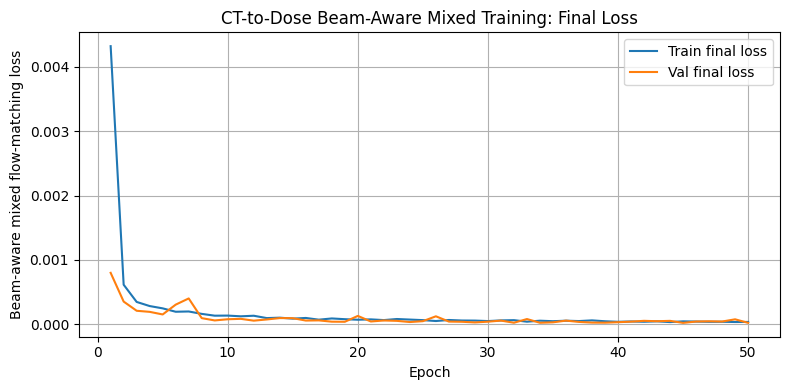

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_beam_aware_mixed_training/ct2dose_phase4_beam_aware_mixed_flow_lr5e4_base24_bs2_T0p15_a0p30_mw3_g1_sz2_sy3_mt4_final_loss_curve.png


In [12]:
plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_final_loss"], label="Train final loss")
plt.plot(history_df["epoch"], history_df["val_final_loss"], label="Val final loss")
plt.xlabel("Epoch")
plt.ylabel("Beam-aware mixed flow-matching loss")
plt.title("CT-to-Dose Beam-Aware Mixed Training: Final Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()

final_loss_curve_path = OUT_DIR / f"{RUN_NAME}_final_loss_curve.png"
plt.savefig(final_loss_curve_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", final_loss_curve_path)

### Cell 13 — Base vs beam-weighted components

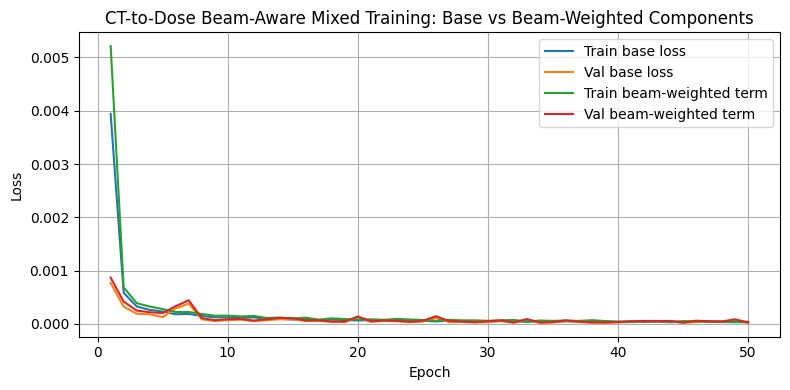

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_beam_aware_mixed_training/ct2dose_phase4_beam_aware_mixed_flow_lr5e4_base24_bs2_T0p15_a0p30_mw3_g1_sz2_sy3_mt4_base_vs_beamweighted_components.png


In [13]:
plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_base_loss"], label="Train base loss")
plt.plot(history_df["epoch"], history_df["val_base_loss"], label="Val base loss")
plt.plot(history_df["epoch"], history_df["train_beam_weighted_loss"], label="Train beam-weighted term")
plt.plot(history_df["epoch"], history_df["val_beam_weighted_loss"], label="Val beam-weighted term")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CT-to-Dose Beam-Aware Mixed Training: Base vs Beam-Weighted Components")
plt.grid(True)
plt.legend()
plt.tight_layout()

component_curve_path = OUT_DIR / f"{RUN_NAME}_base_vs_beamweighted_components.png"
plt.savefig(component_curve_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", component_curve_path)

### Cell 14 — Visualize weight maps on one training sample

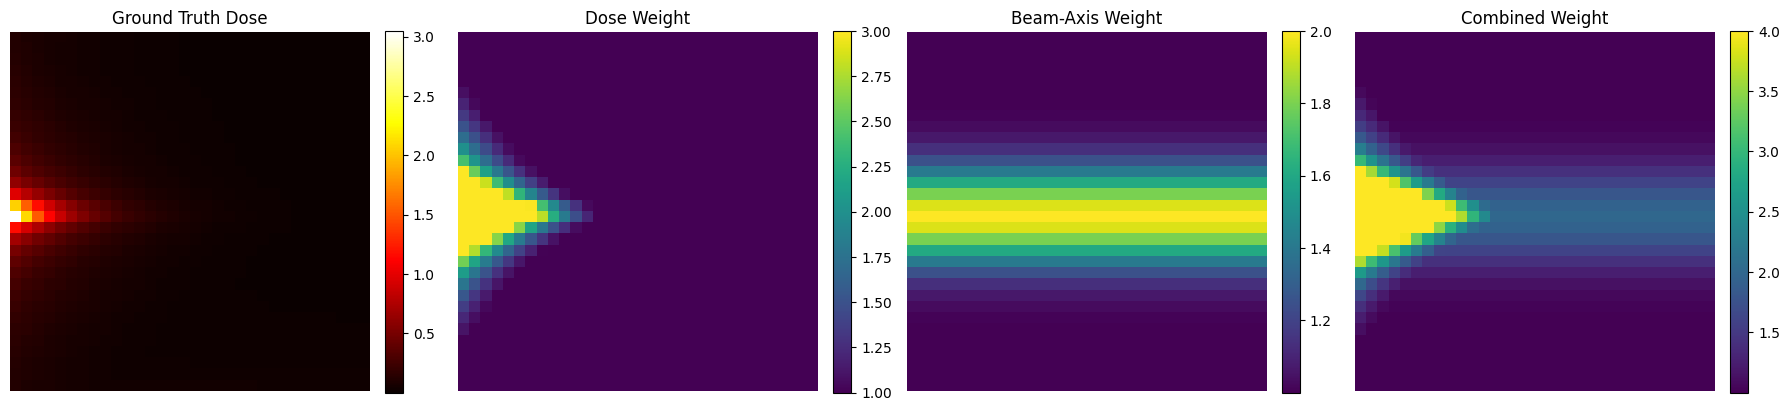

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_beam_aware_mixed_training/ct2dose_phase4_beam_aware_mixed_flow_lr5e4_base24_bs2_T0p15_a0p30_mw3_g1_sz2_sy3_mt4_weight_map_example.png


In [14]:
def infer_beam_center_numpy(gt_vol):
    proj = gt_vol.sum(axis=-1)   # [D,H]
    flat_idx = np.argmax(proj)
    D, H = proj.shape
    zc = flat_idx // H
    yc = flat_idx % H
    return int(zc), int(yc)

sample_idx = len(train_dataset_3d) // 2
x0, x1 = train_dataset_3d[sample_idx]

gt = x1.unsqueeze(0).to(device)  # [1,1,D,H,W]

dose_weight = build_dose_weight_map_from_gt(
    gt, threshold=THRESHOLD, mode=THRESHOLD_MODE, eps=EPS
)
dose_weight = torch.clamp(dose_weight, max=MAX_DOSE_WEIGHT)

beam_weight = build_beam_axis_weight_map(
    gt, gamma=BEAM_GAMMA, sigma_z=SIGMA_Z, sigma_y=SIGMA_Y
)

total_weight = dose_weight * beam_weight
total_weight = torch.clamp(total_weight, max=MAX_TOTAL_WEIGHT)

gt_np = gt.cpu().squeeze().numpy()
dose_weight_np = dose_weight.cpu().squeeze().numpy()
beam_weight_np = beam_weight.cpu().squeeze().numpy()
total_weight_np = total_weight.cpu().squeeze().numpy()

slice_idx = np.argmax(gt_np.reshape(gt_np.shape[0], -1).sum(axis=1))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

im0 = axes[0].imshow(gt_np[slice_idx], cmap="hot")
axes[0].set_title("Ground Truth Dose")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(dose_weight_np[slice_idx], cmap="viridis")
axes[1].set_title("Dose Weight")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(beam_weight_np[slice_idx], cmap="viridis")
axes[2].set_title("Beam-Axis Weight")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

im3 = axes[3].imshow(total_weight_np[slice_idx], cmap="viridis")
axes[3].set_title("Combined Weight")
axes[3].axis("off")
plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

plt.tight_layout()

weight_vis_path = OUT_DIR / f"{RUN_NAME}_weight_map_example.png"
plt.savefig(weight_vis_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", weight_vis_path)